In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [55]:

ENROL_FILES = [
    "api_data_aadhar_enrolment_0_500000.csv",
    "api_data_aadhar_enrolment_500000_1000000.csv",
    "api_data_aadhar_enrolment_1000000_1006029.csv"
]

BIO_FILES = [
    "api_data_aadhar_biometric_0_500000.csv",
    "api_data_aadhar_biometric_500000_1000000.csv",
    "api_data_aadhar_biometric_1000000_1500000.csv",
    "api_data_aadhar_biometric_1500000_1861108.csv"
]

DEMO_FILES = [
    "api_data_aadhar_demographic_0_500000.csv",
    "api_data_aadhar_demographic_500000_1000000.csv",
    "api_data_aadhar_demographic_1000000_1500000.csv",
    "api_data_aadhar_demographic_1500000_2000000.csv",
    "api_data_aadhar_demographic_2000000_2071700.csv"
]

In [56]:
def load_and_merge(files):
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

enrol_df = load_and_merge(ENROL_FILES)
bio_df   = load_and_merge(BIO_FILES)
demo_df  = load_and_merge(DEMO_FILES)


In [57]:
enrol_df["date"] = pd.to_datetime(enrol_df["date"], dayfirst=True, errors="coerce")

enrol_df["total_enrolment"] = (
    enrol_df["age_0_5"] +
    enrol_df["age_5_17"] +
    enrol_df["age_18_greater"]
)

enrol_df.dropna(subset=["date", "state"], inplace=True)

# ---- Biometric ----
bio_df["date"] = pd.to_datetime(bio_df["date"], dayfirst=True, errors="coerce")

bio_df["total_biometric_updates"] = bio_df.drop(
    columns=["date", "state", "district", "pincode"],
    errors="ignore"
).sum(axis=1)

bio_df.dropna(subset=["state"], inplace=True)

# ---- Demographic ----
demo_df.dropna(subset=["state"], inplace=True)

In [58]:
age_distribution = enrol_df[[
    "age_0_5",
    "age_5_17",
    "age_18_greater"
]].sum()

# ---- State-wise Enrolment ----
state_enrolment = (
    enrol_df.groupby("state")["total_enrolment"]
    .sum()
    .sort_values(ascending=False)
)

# ---- Biometric Update Concentration ----
state_biometric = (
    bio_df.groupby("state")["total_biometric_updates"]
    .sum()
    .sort_values(ascending=False)
)

In [61]:
demographic_activity = demo_df[
    ["demo_age_5_17", "demo_age_17_"]
].sum()

In [59]:
bio_mean = state_biometric.mean()
bio_std  = state_biometric.std()

biometric_anomalies = state_biometric[
    state_biometric > (bio_mean + 2 * bio_std)
]

In [60]:
monthly_enrolment = (
    enrol_df
    .groupby(pd.Grouper(key="date", freq="ME"))["total_enrolment"]
    .sum()
)

# Rolling trend (predictive indicator)
rolling_6m_trend = monthly_enrolment.rolling(window=6).mean()

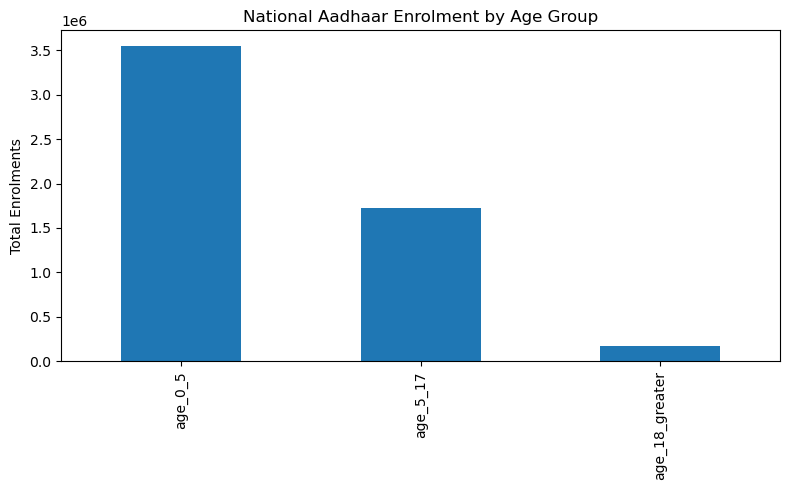

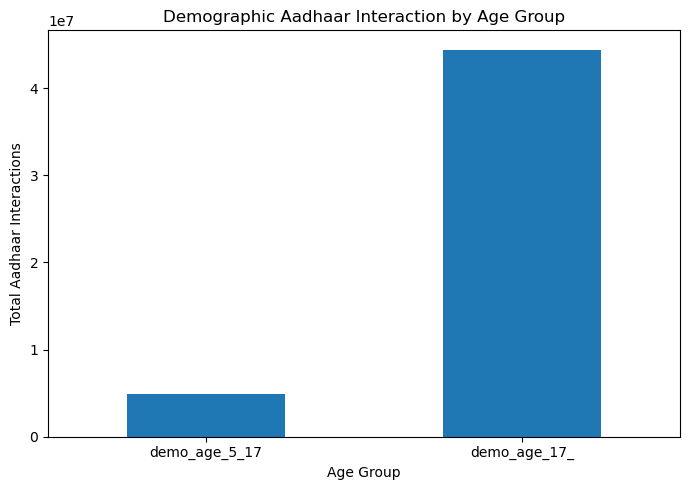

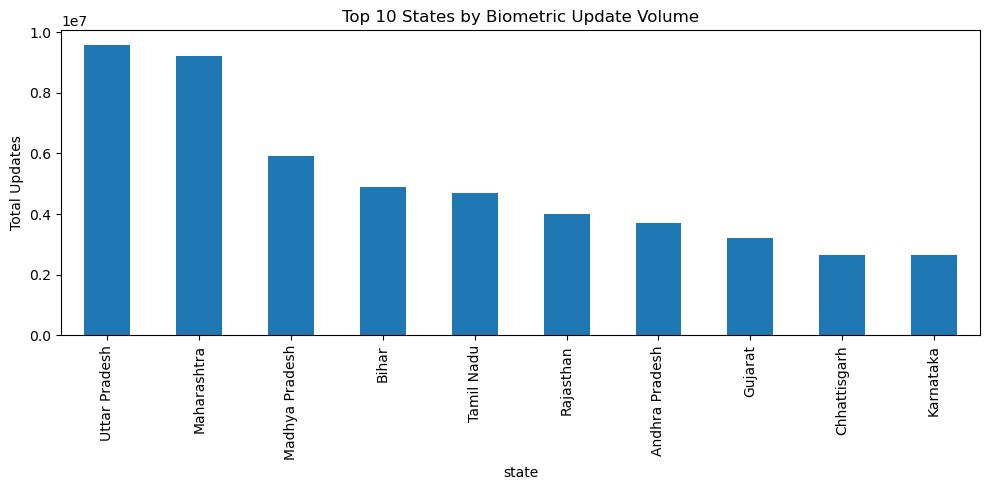

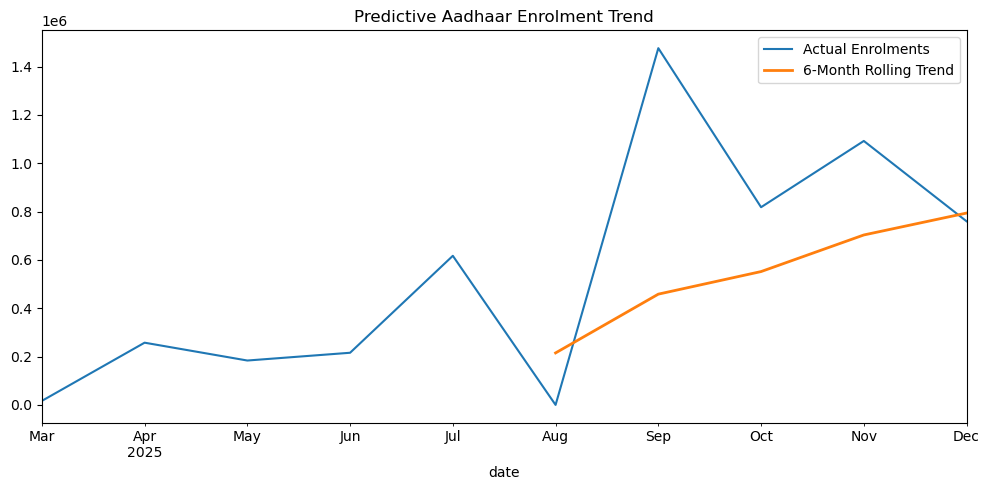

In [62]:
plt.figure(figsize=(8,5))
age_distribution.plot(kind="bar")
plt.title("National Aadhaar Enrolment by Age Group")
plt.ylabel("Total Enrolments")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
demographic_activity.plot(kind="bar")
plt.title("Demographic Aadhaar Interaction by Age Group")
plt.ylabel("Total Aadhaar Interactions")
plt.xlabel("Age Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
state_biometric.head(10).plot(kind="bar")
plt.title("Top 10 States by Biometric Update Volume")
plt.ylabel("Total Updates")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
monthly_enrolment.plot(label="Actual Enrolments")
rolling_6m_trend.plot(label="6-Month Rolling Trend", linewidth=2)
plt.title("Predictive Aadhaar Enrolment Trend")
plt.legend()
plt.tight_layout()
plt.show()



In [63]:
print("\n--- KEY ANALYTICAL INSIGHTS ---\n")

print("1. Aadhaar enrolment is adult-dominated, confirming life-cycle identity usage.\n")

print("2. Biometric update activity is highly concentrated in a few states,")
print("   indicating biometric ageing and occupational impact.\n")

print("3. Enrolment demand follows predictable monthly patterns,")
print("   enabling proactive infrastructure planning.\n")

print("4. States with anomalously high biometric updates:")
print(biometric_anomalies)


--- KEY ANALYTICAL INSIGHTS ---

1. Aadhaar enrolment is adult-dominated, confirming life-cycle identity usage.

2. Biometric update activity is highly concentrated in a few states,
   indicating biometric ageing and occupational impact.

3. Enrolment demand follows predictable monthly patterns,
   enabling proactive infrastructure planning.

4. States with anomalously high biometric updates:
state
Uttar Pradesh     9577735
Maharashtra       9226139
Madhya Pradesh    5923771
Name: total_biometric_updates, dtype: int64


In [64]:
forecast_indicator = rolling_6m_trend.iloc[-1]
print("\nPredicted near-term monthly enrolment demand (trend-based):")
print(forecast_indicator)



Predicted near-term monthly enrolment demand (trend-based):
793722.0
